# Predicting the Duration of a Taxi Ride
In this notebook, we will create a machine learning model to predict the duration of a taxi ride based on different parameters.

In [31]:
import pickle

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

In [2]:
df = pd.read_parquet("../data/green_taxi/green_tripdata_2021-01.parquet")
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.50,0.50,0.5,0.00,0.00,None,0.3,6.80,2.0,1.0,0.00
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.00,0.50,0.5,2.81,0.00,None,0.3,16.86,1.0,1.0,2.75
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.00,0.50,0.5,1.00,0.00,None,0.3,8.30,1.0,1.0,0.00
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.00,0.50,0.5,0.00,0.00,None,0.3,9.30,2.0,1.0,0.00
4,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,-52.00,0.00,-0.5,0.00,0.00,None,-0.3,-52.80,3.0,1.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76513,2,2021-01-31 21:38:00,2021-01-31 22:16:00,None,NaN,81,90,NaN,17.63,56.23,2.75,0.0,0.00,6.12,None,0.3,65.40,NaN,NaN,NaN
76514,2,2021-01-31 22:43:00,2021-01-31 23:21:00,None,NaN,35,213,NaN,18.36,46.66,0.00,0.0,12.20,6.12,None,0.3,65.28,NaN,NaN,NaN
76515,2,2021-01-31 22:16:00,2021-01-31 22:27:00,None,NaN,74,69,NaN,2.50,18.95,2.75,0.0,0.00,0.00,None,0.3,22.00,NaN,NaN,NaN
76516,2,2021-01-31 23:10:00,2021-01-31 23:37:00,None,NaN,168,215,NaN,14.48,48.87,2.75,0.0,0.00,6.12,None,0.3,58.04,NaN,NaN,NaN


`trip_type` represents how the taxi was called. If it was hailed from the street, the value of this column is 1. If it was dispatched (possibly after a call), the column value is 2.

## Compute duration
We compute the duration of each ride based on the start and end time of a trip.

In [3]:
df.loc[:, "lpep_pickup_datetime"] = pd.to_datetime(
    df["lpep_pickup_datetime"], format="%Y-%m-%d %H:%M:%S"
)
df.loc[:, "lpep_dropoff_datetime"] = pd.to_datetime(
    df["lpep_dropoff_datetime"], format="%Y-%m-%d %H:%M:%S"
)
df.loc[:, "duration"] = (
    df["lpep_dropoff_datetime"] - df["lpep_pickup_datetime"]
).dt.total_seconds() / 60
df = df.reset_index(drop=True)
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.50,...,0.5,0.00,0.00,None,0.3,6.80,2.0,1.0,0.00,3.933333
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.00,...,0.5,2.81,0.00,None,0.3,16.86,1.0,1.0,2.75,8.750000
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.00,...,0.5,1.00,0.00,None,0.3,8.30,1.0,1.0,0.00,5.966667
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.00,...,0.5,0.00,0.00,None,0.3,9.30,2.0,1.0,0.00,7.083333
4,2,2021-01-01 00:16:36,2021-01-01 00:16:40,N,2.0,265,265,3.0,0.00,-52.00,...,-0.5,0.00,0.00,None,-0.3,-52.80,3.0,1.0,0.00,0.066667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76513,2,2021-01-31 21:38:00,2021-01-31 22:16:00,None,NaN,81,90,NaN,17.63,56.23,...,0.0,0.00,6.12,None,0.3,65.40,NaN,NaN,NaN,38.000000
76514,2,2021-01-31 22:43:00,2021-01-31 23:21:00,None,NaN,35,213,NaN,18.36,46.66,...,0.0,12.20,6.12,None,0.3,65.28,NaN,NaN,NaN,38.000000
76515,2,2021-01-31 22:16:00,2021-01-31 22:27:00,None,NaN,74,69,NaN,2.50,18.95,...,0.0,0.00,0.00,None,0.3,22.00,NaN,NaN,NaN,11.000000
76516,2,2021-01-31 23:10:00,2021-01-31 23:37:00,None,NaN,168,215,NaN,14.48,48.87,...,0.0,0.00,6.12,None,0.3,58.04,NaN,NaN,NaN,27.000000


In [4]:
df["duration"].describe(percentiles=[0.01, 0.02, 0.25, 0.5, 0.75, 0.98, 0.99])

count    76518.000000
mean        19.927896
std         59.338594
min          0.000000
1%           0.200000
2%           1.016667
25%          8.000000
50%         13.883333
75%         23.000000
98%         56.000000
99%         67.158167
max       1439.600000
Name: duration, dtype: float64

Based on the description of ride durations, we can make the following observations:
- Some trips are too long (almost an entire day) while others are too short (less than a minute).
- 98% of trips have a duration less than 1 hour which sounds reasonable.
- About 2% of the trips have a duration of less than 1 minute.

Given these observations, we filter the data for trips greater than 1 minute and less than an hour.

In [5]:
df = df[(df["duration"] >= 1) & (df["duration"] <= 60)]
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,duration
0,2,2021-01-01 00:15:56,2021-01-01 00:19:52,N,1.0,43,151,1.0,1.01,5.50,...,0.5,0.00,0.00,None,0.3,6.80,2.0,1.0,0.00,3.933333
1,2,2021-01-01 00:25:59,2021-01-01 00:34:44,N,1.0,166,239,1.0,2.53,10.00,...,0.5,2.81,0.00,None,0.3,16.86,1.0,1.0,2.75,8.750000
2,2,2021-01-01 00:45:57,2021-01-01 00:51:55,N,1.0,41,42,1.0,1.12,6.00,...,0.5,1.00,0.00,None,0.3,8.30,1.0,1.0,0.00,5.966667
3,2,2020-12-31 23:57:51,2021-01-01 00:04:56,N,1.0,168,75,1.0,1.99,8.00,...,0.5,0.00,0.00,None,0.3,9.30,2.0,1.0,0.00,7.083333
7,2,2021-01-01 00:26:31,2021-01-01 00:28:50,N,1.0,75,75,6.0,0.45,3.50,...,0.5,0.96,0.00,None,0.3,5.76,1.0,1.0,0.00,2.316667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76513,2,2021-01-31 21:38:00,2021-01-31 22:16:00,None,NaN,81,90,NaN,17.63,56.23,...,0.0,0.00,6.12,None,0.3,65.40,NaN,NaN,NaN,38.000000
76514,2,2021-01-31 22:43:00,2021-01-31 23:21:00,None,NaN,35,213,NaN,18.36,46.66,...,0.0,12.20,6.12,None,0.3,65.28,NaN,NaN,NaN,38.000000
76515,2,2021-01-31 22:16:00,2021-01-31 22:27:00,None,NaN,74,69,NaN,2.50,18.95,...,0.0,0.00,0.00,None,0.3,22.00,NaN,NaN,NaN,11.000000
76516,2,2021-01-31 23:10:00,2021-01-31 23:37:00,None,NaN,168,215,NaN,14.48,48.87,...,0.0,0.00,6.12,None,0.3,58.04,NaN,NaN,NaN,27.000000


## Feature selection
We define numeric and categorical features that act as predictors in our model. To begin with, we choose the pickup location ID, dropoff location ID, and trip distance as the features.

In [6]:
categorical_vars = ["PULocationID", "DOLocationID"]
numerical_vars = ["trip_distance"]

We encode the categorical variables as one-hot vectors before using them as model features.

In [7]:
# Convert the location IDs from integers to strings so that they can
# be converted to one-hot encoded features by DictVectorizer.
df.loc[:, categorical_vars] = df[categorical_vars].astype(str)

/tmp/ipykernel_9213/2277575426.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['43' '166' '41' ... '74' '168' '119']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, categorical_vars] = df[categorical_vars].astype(str)
/tmp/ipykernel_9213/2277575426.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['151' '239' '42' ... '69' '215' '244']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, categorical_vars] = df[categorical_vars].astype(str)


In [8]:
# We pass all features to DictVectorizer, including the numerical ones as
# it skips numerical features by default.
train_dict = df[categorical_vars + numerical_vars].to_dict(orient="records")

In [9]:
dv = DictVectorizer()
X_train = dv.fit_transform(train_dict)
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 221724 stored elements and shape (73908, 507)>

We print the features names created by CV to ensure that the one-hot encoding is complete. For the categorical variables, the feature names should include separate features for each category.

In [10]:
dv.feature_names_

['DOLocationID=1',
 'DOLocationID=10',
 'DOLocationID=100',
 'DOLocationID=101',
 'DOLocationID=102',
 'DOLocationID=106',
 'DOLocationID=107',
 'DOLocationID=108',
 'DOLocationID=109',
 'DOLocationID=11',
 'DOLocationID=111',
 'DOLocationID=112',
 'DOLocationID=113',
 'DOLocationID=114',
 'DOLocationID=115',
 'DOLocationID=116',
 'DOLocationID=117',
 'DOLocationID=118',
 'DOLocationID=119',
 'DOLocationID=12',
 'DOLocationID=120',
 'DOLocationID=121',
 'DOLocationID=122',
 'DOLocationID=123',
 'DOLocationID=124',
 'DOLocationID=125',
 'DOLocationID=126',
 'DOLocationID=127',
 'DOLocationID=128',
 'DOLocationID=129',
 'DOLocationID=13',
 'DOLocationID=130',
 'DOLocationID=131',
 'DOLocationID=132',
 'DOLocationID=133',
 'DOLocationID=134',
 'DOLocationID=135',
 'DOLocationID=136',
 'DOLocationID=137',
 'DOLocationID=138',
 'DOLocationID=139',
 'DOLocationID=14',
 'DOLocationID=140',
 'DOLocationID=141',
 'DOLocationID=142',
 'DOLocationID=143',
 'DOLocationID=144',
 'DOLocationID=145',

In [11]:
target = "duration"
y_train = df[target].values
y_train

array([ 3.93333333,  8.75      ,  5.96666667, ..., 11.        ,
       27.        , 10.        ], shape=(73908,))

## Model fit
Next, we fit a linear regression model to the data.

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Visualise model predictions
We now compare the distribution of actual durations against predicted durations from the linear regression model.

In [13]:
y_pred = lr.predict(X_train)

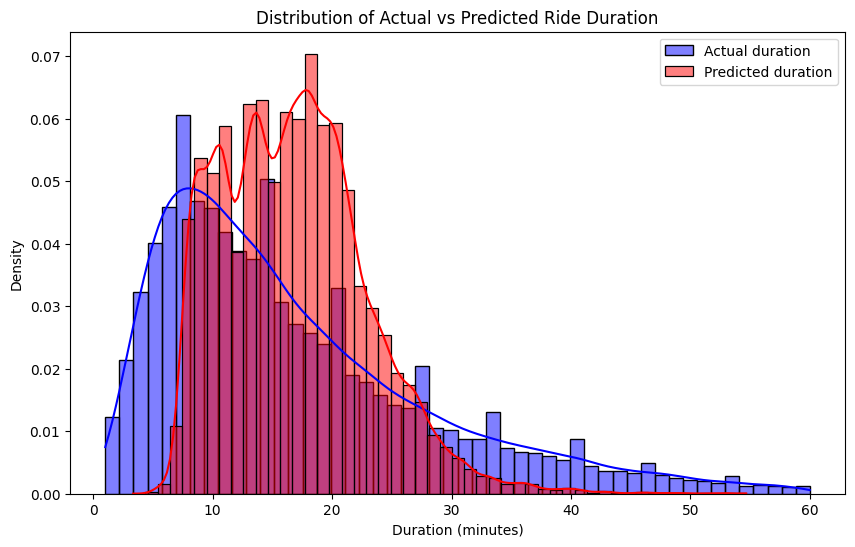

In [16]:
plt.figure(figsize=(10, 6))
sns.histplot(
    y_train,
    color="blue",
    label="Actual duration",
    kde=True,
    stat="density",
    bins=50,
    alpha=0.5,
)
sns.histplot(
    y_pred,
    color="red",
    label="Predicted duration",
    kde=True,
    stat="density",
    bins=50,
    alpha=0.5,
)
plt.xlabel("Duration (minutes)")
plt.ylabel("Density")
plt.legend()
plt.title("Distribution of Actual vs Predicted Ride Duration")
plt.show()

## Metrics
Next, we compute the error between the actuals and the predictions. Since it's a regression problem, we use mean absolute error as the baseline.

In [21]:
mean_absolute_error(y_train, y_pred)

7.232015676443476

In [24]:
mean_absolute_percentage_error(y_train, y_pred)

0.7156461081049312

The error indicates that our model currently gets the duration prediction wrong by about 7 minutes which is equivalent to a 72% deviation from the actual duration. This is a large deviation and indicates that we need to find a better solution.

A problem with our existing approach is that we use the entire available data for training and then re-use it for inference. The best practice is to split the data into training and test sets so that the model can generalise better and perform well on data it has not seen before. In order to do so, we first refactor the code to make it easier to execute for multiple data sources and dataframes.

## Code refactor
First, we collect the data preprocessing steps into a single function.

In [26]:
def load_and_process_dataframe(filename: str) -> pd.DataFrame:
    """
    Loads a parquet file containing taxi trip data, processes datetime columns,
    computes trip duration in minutes, filters out trips with duration < 1 or > 60 minutes,
    and converts categorical location ID columns to string type for one-hot encoding.

    Parameters
    ----------
    filename : str
        Path to the parquet file to load.

    Returns
    -------
    pd.DataFrame
        Processed DataFrame ready for feature extraction and modeling.
    """
    # Load the parquet file into a DataFrame
    df = pd.read_parquet(filename)

    # Convert pickup and dropoff columns to datetime
    df.loc[:, "lpep_pickup_datetime"] = pd.to_datetime(
        df["lpep_pickup_datetime"], format="%Y-%m-%d %H:%M:%S"
    )
    df.loc[:, "lpep_dropoff_datetime"] = pd.to_datetime(
        df["lpep_dropoff_datetime"], format="%Y-%m-%d %H:%M:%S"
    )

    # Compute trip duration in minutes
    df.loc[:, "duration"] = (
        df["lpep_dropoff_datetime"] - df["lpep_pickup_datetime"]
    ).dt.total_seconds() / 60

    # Reset index after filtering
    df = df.reset_index(drop=True)

    # Filter trips to keep only those with reasonable durations
    df = df[(df["duration"] >= 1) & (df["duration"] <= 60)]

    # Convert location ID columns to string for one-hot encoding
    categorical_vars = ["PULocationID", "DOLocationID"]
    df.loc[:, categorical_vars] = df[categorical_vars].astype(str)

    return df

We now load the trip data for January 2021 to train the model and then use the data from February 2021 to evaluate the model.

In [27]:
df_train = load_and_process_dataframe("../data/green_taxi/green_tripdata_2021-01.parquet")
df_test = load_and_process_dataframe("../data/green_taxi/green_tripdata_2021-02.parquet")

/tmp/ipykernel_9213/4139724893.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['43' '166' '41' ... '74' '168' '119']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, categorical_vars] = df[categorical_vars].astype(str)
/tmp/ipykernel_9213/4139724893.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['151' '239' '42' ... '69' '215' '244']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, categorical_vars] = df[categorical_vars].astype(str)
/tmp/ipykernel_9213/4139724893.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '['130' '152' '152' ... '74' '42' '42']' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, categori

We now convert the categorical variables to one-hot encodings. In this transformation, we take care to fit the vectoriser only to the training data and use these fits to transform both the training and test data.

In [28]:
dv = DictVectorizer()
train_dicts = df_train[categorical_vars + numerical_vars].to_dict(orient="records")
X_train = dv.fit_transform(train_dicts)

test_dicts = df_test[categorical_vars + numerical_vars].to_dict(orient="records")
X_test = dv.transform(test_dicts)

In [29]:
target = "duration"
y_train = df_train[target].values
y_test = df_test[target].values

In [30]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

mean_absolute_error(y_test, y_pred), mean_absolute_percentage_error(y_test, y_pred)

(7.603779099246167, 0.6612357698493491)

In [33]:
# Save the model and DictVectorizer to disk
with open("../models/green_taxi_lin_reg.bin", "wb") as f_out:
    pickle.dump((dv, lr), f_out)

Based on the metrics, we can observe that the model performs slightly poorly on the test set (7.6 minutes compared to 7.2 minutes on the training set). The mean absolute percentage error is surprisingly lower on the test set (66% compared to 72% on the training set). Regardless, the metrics indicate that the model is a poor fit to the data. 

To derive a model that fits the data better, we can:
- Experiment with alternative linear regression models that include regularisation like Lasso or Ridge.
- Include additional features, derive new features from existing features, or remoe existing features.  